In [1]:
from transformers import AutoImageProcessor
import torch.optim as optim
import webdataset as wds
from pathlib import Path
from modules import *
import csv
import argparse
import os

In [2]:
TRAIN_DATASET_PATH = "/home/austen/GeoDataset/dataset_sharded"
TRAIN_S2_LABELS_DIR = Path(TRAIN_DATASET_PATH) / "s2_labels"
TEST_DATASET_PATH = "/home/austen/GeoDataset/dataset_sharded_TEST"
BATCH_SIZE = 4
WORKERS = 4
S2_LEVELS = list(range(3, 8))
PRETRAINED_MODEL_ID = "facebook/convnext-base-384"
CHECKPOINT_PATH = "checkpoints/checkpoint_V4.pt"
DEVICE = "cuda"
RESIZE = 384
IMAGES = 2048

Epoch: 63


Evaluating:  99%|█████████▉| 509/512 [00:29<00:00, 17.37it/s]


Mean top-1 geodesic error (km): 586.1040649414062


,Top-k,S2 level,Accuracy,Random baseline
0,1,3,0.7132,0.0058
1,1,4,0.6130,0.0022
2,1,5,0.4730,0.0008
3,1,6,0.3374,0.0003
4,1,7,0.2323,0.0001
5,5,3,0.9263,0.0289
6,5,4,0.9091,0.0111
7,5,5,0.8183,0.0039
8,5,6,0.6562,0.0013
9,5,7,0.4862,0.0005


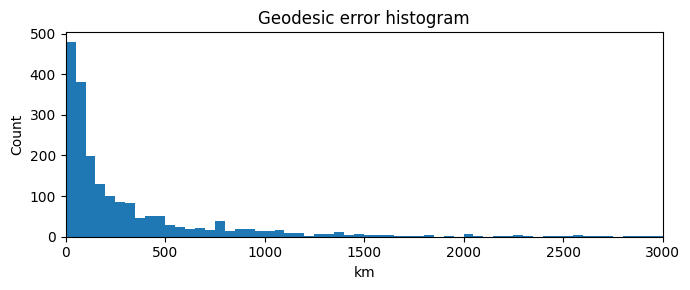

In [3]:
processor = AutoImageProcessor.from_pretrained(PRETRAINED_MODEL_ID, use_fast=True)
processor.do_resize = True
processor.size = {"shortest_edge": RESIZE}

idx2id, id2idx, num_classes = build_s2_index_maps(TRAIN_S2_LABELS_DIR, S2_LEVELS)
parent_tables = build_parent_tables_from_maps(idx2id, id2idx, S2_LEVELS)

dataset = GeoWebDataset(
    TEST_DATASET_PATH,
    processor,
    levels=S2_LEVELS,
    shuffle=True,
    num_shards_limit=None,
    id2idx=id2idx,
)

num_fine_classes = len(id2idx[S2_LEVELS[-1]])

model = HierarchicalConvNeXt(
    pretrained_name=PRETRAINED_MODEL_ID,
    num_classes=num_fine_classes,
    freeze=False,
)

loader = wds.WebLoader(
    dataset.dataset,
    num_workers=WORKERS,
    batch_size=BATCH_SIZE,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

evaluator = Evaluator(
    model=model, 
    loader=loader, 
    s2_levels=S2_LEVELS, 
    parent_maps=parent_tables,
    num_classes_per_level=dataset.num_classes_list, 
    idx2id=idx2id
).to(DEVICE)

evaluator.load_checkpoint(CHECKPOINT_PATH)
out = evaluator(max_batches=IMAGES // BATCH_SIZE)
out